In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import json

import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 12

In [2]:
base_dir = "../../251029/"
processed_data_dir = base_dir + "science-data_and_code/data/processed_data/"
df_paired_val = pd.read_csv(processed_data_dir + "df_paired_val.csv")
df_paired_learn = pd.read_csv(processed_data_dir + "df_paired_learn.csv")
df_analysis_val = pd.read_csv(processed_data_dir + "df_analysis_val.csv")
df_analysis_learn = pd.read_csv(processed_data_dir + "df_analysis_learn.csv")
df_rounds_learn = pd.read_csv(processed_data_dir + "df_rounds_learn.csv")
df_rounds_val = pd.read_csv(processed_data_dir + "df_rounds_val.csv")
df_predictions = pd.read_csv(processed_data_dir + "prediction_survey.csv").query("prediction.between(-0.2,1.2)")
#df_learning_config = pd.read_csv("../data/exp_config_files/learning.csv")
#df_validation_config = pd.read_csv("../data/exp_config_files/validation.csv")

df_rounds_learn = df_rounds_learn.merge(df_analysis_learn, on="gameId", how="left").query("valid_number_of_starting_players == True").dropna(subset=["data.roundPayoff"]).reset_index(drop=True)
df_rounds_val = df_rounds_val.merge(df_analysis_val, on="gameId", how="left").query("valid_number_of_starting_players == True").dropna(subset=["data.roundPayoff"]).reset_index(drop=True)

In [3]:
df_paired_val["woc_sspp_pred"] = df_paired_val["CONFIG_configId"].map(df_predictions.query("source == 'sspp'").groupby("CONFIG_configId")["prediction"].mean())
df_paired_val["woc_prolific_pred"] = df_paired_val["CONFIG_configId"].map(df_predictions.query("source == 'prolific'").groupby("CONFIG_configId")["prediction"].mean())

In [5]:
def index_of_median_value(s):
    """
    Return the index of the actual data point closest to the median.
    Works for both even and odd-length Series.
    """
    med = s.median()
    return (s - med).abs().idxmin()

In [6]:
ind_median_sspp = index_of_median_value(df_predictions.query("(source == 'sspp') & (n_predictions_made == 20)").groupby('playerID')['squared_error'].mean())
ind_best_sspp = df_predictions.query("(source == 'sspp') & (n_predictions_made == 20)").groupby('playerID')['squared_error'].mean().idxmin()
ind_median_prolific = index_of_median_value(df_predictions.query("(source == 'prolific') & (n_predictions_made == 20)").groupby('playerID')['squared_error'].mean())
ind_best_prolific = df_predictions.query("(source == 'prolific') & (n_predictions_made == 20)").groupby('playerID')['squared_error'].mean().idxmin()

In [7]:
df_pgg = pd.read_csv(base_dir + 'input/pgg_validation_basePrompt.csv')

In [8]:
df_paired_val["median_sspp_pred"] = df_paired_val["CONFIG_configId"].map(
    df_predictions
    .query("playerID == @ind_median_sspp")
    .set_index("CONFIG_configId")["prediction"]
)


df_paired_val["best_sspp_pred"] = df_paired_val["CONFIG_configId"].map(
    df_predictions
    .query("playerID == @ind_best_sspp")
    .set_index("CONFIG_configId")["prediction"]
)

df_paired_val["median_prolific_pred"] = df_paired_val["CONFIG_configId"].map(
    df_predictions
    .query("playerID == @ind_median_prolific")
    .set_index("CONFIG_configId")["prediction"]
)


df_paired_val["best_prolific_pred"] = df_paired_val["CONFIG_configId"].map(
    df_predictions
    .query("playerID == @ind_best_prolific")
    .set_index("CONFIG_configId")["prediction"]
)

In [9]:
df_base_predictions = df_paired_val.set_index("CONFIG_configId")[
    [
    "treatment_itt_efficiency",
    "elastic_prereg_pred",
    "woc_sspp_pred",
    "woc_prolific_pred",
    "median_sspp_pred",
    "best_sspp_pred",
    "median_prolific_pred",
    "best_prolific_pred",
]
].sort_index() * 100

In [10]:
df_base_se = (df_base_predictions.sub(df_base_predictions.treatment_itt_efficiency, axis=0)**2).iloc[:,1:].rename(columns=lambda c: c.replace("_pred", ""))

In [11]:
df_base_se["baseline"] = pd.read_csv(base_dir + 'output/se_baseline_GPT41.csv', index_col=0).values[0]

In [13]:
df_laypeople_se = ((df_predictions.query("(source == 'prolific') & (n_predictions_made == 20)").pivot(
    index="CONFIG_configId",
    columns="playerID",
    values="prediction",
)* 100).sub(df_base_predictions.treatment_itt_efficiency, axis=0)**2).T

In [14]:
df_experts_se = ((df_predictions.query("(source == 'sspp') & (n_predictions_made == 20)").pivot(
    index="CONFIG_configId",
    columns="playerID",
    values="prediction",
)* 100).sub(df_base_predictions.treatment_itt_efficiency, axis=0)**2).T

In [32]:
df_base_se

,elastic_prereg,woc_sspp,woc_prolific,median_sspp,best_sspp,median_prolific,best_prolific,baseline
CONFIG_configId,,,,,,,,
0,15.227696,11.180211,91.355921,0.013849,4.484578,15.072392,9.719942,180.066381
1,88.931571,285.685877,83.301725,405.083618,365.830239,405.083618,123.803212,149.926251
2,0.466314,31.557305,16.784168,32.541839,32.541839,67.314566,28.041839,16.887768
3,1.013420,66.873416,212.203145,2.744931,135.880601,19.862919,0.431365,95.463042
4,27.306711,12.799202,6.356632,16.748481,25.933463,92.015881,9.563500,1.727951
5,0.314997,71.313359,6.625879,157.097500,90.894375,144.813646,42.691250,81.074726
6,30.968893,24.429710,2.063407,99.290836,80.361878,212.124040,0.930219,9.209897
7,4.589685,37.877714,0.110251,74.417888,58.164727,102.547629,13.152085,15.534044
8,6.144619,27.903969,0.504074,148.665285,23.108812,75.565423,26.965561,0.000113


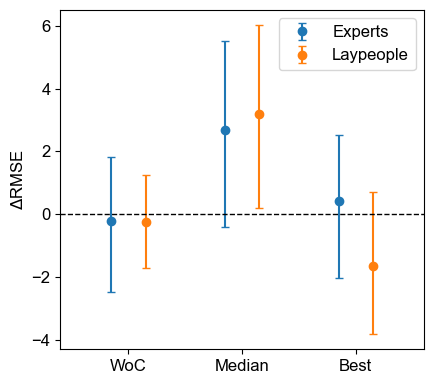

In [15]:
import numpy as np
import matplotlib.pyplot as plt

baseline_se = df_base_se['baseline'].values
n_pairs = len(df_base_se)
n_boot = 10000
rng = np.random.default_rng(seed=42)

def delta_rmse(se_model, se_base):
    """RMSE(model) - RMSE(baseline)."""
    rmse_model = np.sqrt(se_model.mean())
    rmse_base  = np.sqrt(se_base.mean())
    return rmse_model - rmse_base

def bootstrap_delta_rmse(se_model, se_base, n_boot=10000, rng=None):
    """Paired bootstrap over rows to get CI for ΔRMSE."""
    if rng is None:
        rng = np.random.default_rng()
    n = len(se_model)
    boot_vals = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)  # resample rows with replacement
        boot_vals[b] = delta_rmse(se_model[idx], se_base[idx])
    lo, hi = np.percentile(boot_vals, [2.5, 97.5])
    return boot_vals.mean(), lo, hi

# Grouping: (experts, laypeople) within each of Wisdom of Crowds / Median / Best
groups = [
    ('woc_sspp',        'woc_prolific',        'WoC'),
    ('median_sspp',     'median_prolific',     'Median'),
    ('best_sspp',       'best_prolific',       'Best'),
]

group_x = np.arange(len(groups))   # 0, 1, 2
offset = 0.15
color_expert = 'tab:blue'
color_lay    = 'tab:orange'

fig, ax = plt.subplots(figsize=(4.5, 4))  # narrower figure

legend_done = {'Experts': False, 'Laypeople': False}

for i, (col_expert, col_lay, group_label) in enumerate(groups):
    # Experts
    se_exp = df_base_se[col_expert].values
    est_exp, lo_exp, hi_exp = bootstrap_delta_rmse(se_exp, baseline_se, n_boot=n_boot, rng=rng)
    x_exp = group_x[i] - offset
    yerr_exp = [[est_exp - lo_exp], [hi_exp - est_exp]]

    ax.errorbar(
        x_exp, est_exp, yerr=yerr_exp,
        fmt='o', color=color_expert, ecolor=color_expert,
        capsize=3, linestyle='none',
        label='Experts' if not legend_done['Experts'] else None
    )
    legend_done['Experts'] = True

    # Laypeople
    se_lay = df_base_se[col_lay].values
    est_lay, lo_lay, hi_lay = bootstrap_delta_rmse(se_lay, baseline_se, n_boot=n_boot, rng=rng)
    x_lay = group_x[i] + offset
    yerr_lay = [[est_lay - lo_lay], [hi_lay - est_lay]]

    ax.errorbar(
        x_lay, est_lay, yerr=yerr_lay,
        fmt='o', color=color_lay, ecolor=color_lay,
        capsize=3, linestyle='none',
        label='Laypeople' if not legend_done['Laypeople'] else None
    )
    legend_done['Laypeople'] = True

# Horizontal line at 0 (no difference from baseline)
ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

# x-ticks at group centers
ax.set_xticks(group_x)
ax.set_xticklabels([g[2] for g in groups], rotation=0, ha='center')

ax.set_ylabel(r'$\Delta$RMSE')

# Make x-range tight around the groups
ax.set_xlim(-0.6, len(groups) - 0.4)

ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_delta_rmse_individuals_simple(
    df_base_se,
    group_to_df,
    baseline_col="baseline",
    n_boot=2000,
    ax=None,
    random_state=42,
):
    """
    Simple per-forecaster ΔRMSE plot (forecaster − GPT-4.1 baseline).

    Parameters
    ----------
    df_base_se : pd.DataFrame
        Rows = designs; must contain a column `baseline_col`
        with squared errors (SE) for GPT-4.1 for each design.

    group_to_df : dict[str, pd.DataFrame]
        Mapping {group_name -> df_forecaster_se}.
        Each df_forecaster_se has:
          - rows = forecasters in that group
          - columns = designs (aligned with df_base_se rows)
          - values = squared error for that forecaster on that design.

    baseline_col : str
        Name of the baseline SE column in df_base_se.

    n_boot : int
        Number of bootstrap draws per forecaster for CIs.

    ax : matplotlib.axes.Axes or None
        If provided, plot into this axes; otherwise create a new one.

    random_state : int
        Seed for RNG.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    rng = np.random.default_rng(random_state)

    # --- baseline SE over designs ---
    baseline_se = df_base_se[baseline_col].values
    J = len(baseline_se)

    # helper: bootstrap ΔRMSE for one forecaster
    def bootstrap_delta_rmse(se_model):
        rmse_model = np.sqrt(np.nanmean(se_model))
        rmse_base = np.sqrt(np.nanmean(baseline_se))
        est = rmse_model - rmse_base

        boot_vals = np.empty(n_boot)
        for b in range(n_boot):
            idx = rng.integers(0, J, size=J)
            se_m = se_model[idx]
            se_b = baseline_se[idx]
            rmse_m = np.sqrt(np.nanmean(se_m))
            rmse_b = np.sqrt(np.nanmean(se_b))
            boot_vals[b] = rmse_m - rmse_b

        lo, hi = np.percentile(boot_vals, [2.5, 97.5])
        return est, lo, hi

    # --- collect per-forecaster estimates ---
    all_est, all_lo, all_hi, all_group = [], [], [], []

    for group_name, df_se in group_to_df.items():
        se_forecasters = df_se.values  # shape (N_g, J)
        N_g, J_g = se_forecasters.shape
        assert J_g == J, "Design columns must align with df_base_se"

        for i in range(N_g):
            est, lo, hi = bootstrap_delta_rmse(se_forecasters[i, :])
            all_est.append(est)
            all_lo.append(lo)
            all_hi.append(hi)
            all_group.append(group_name)

    all_est = np.array(all_est)
    all_lo = np.array(all_lo)
    all_hi = np.array(all_hi)
    all_group = np.array(all_group)

    # significance flags
    sig_better = all_hi < 0
    sig_worse  = all_lo > 0
    sig_none   = ~(sig_better | sig_worse)

    # --- set group order: Experts left, Laypeople right ---
    desired_order = ["Experts", "Laypeople"]
    group_names = [g for g in desired_order if g in group_to_df]
    x_centers = {g: i for i, g in enumerate(group_names)}  # 0, 1, ...

    # jitter within each group
    jitter_width = 0.15
    xs = np.array([
        x_centers[g] + rng.uniform(-jitter_width, jitter_width)
        for g in all_group
    ])

    # --- scatter points (alpha = 0.2) ---
    ax.scatter(xs[sig_none],   all_est[sig_none],
               color='0.7',       alpha=0.2, s=20)
    ax.scatter(xs[sig_better], all_est[sig_better],
               color='tab:green', alpha=0.2, s=25)
    ax.scatter(xs[sig_worse],  all_est[sig_worse],
               color='tab:red',   alpha=0.2, s=25)

    # group medians as black diamonds
    for g, xc in x_centers.items():
        mask = (all_group == g)
        median_est = np.median(all_est[mask])
        ax.scatter(xc, median_est, marker='D',
                   color='black', s=40, zorder=3)

    # baseline line
    ax.axhline(0.0, linestyle='--', color='black', linewidth=1)
    ax.set_ylabel(r'$\Delta$RMSE')

    # --- percentage significantly worse per group ---
    pct_worse_by_group = {}
    for g in group_names:
        mask = (all_group == g)
        if mask.sum() == 0:
            pct_worse_by_group[g] = np.nan
        else:
            frac_worse = sig_worse[mask].sum() / mask.sum()
            pct_worse_by_group[g] = 100 * frac_worse

    # x ticks: group names only
    tick_positions = [x_centers[g] for g in group_names]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(group_names)

    # --- red dot + black text under each group label ---
    # use x-axis transform (x in data coords, y in axes fraction)
    trans = ax.get_xaxis_transform()
    y_text = -0.12  # below the axis; adjust if needed

    for g in group_names:
        pct = pct_worse_by_group[g]
        if np.isnan(pct):
            continue
        xc = x_centers[g]

        # red dot slightly left of centre
        x_dot = xc - 0.18
        # text just to the right of dot
        x_text = xc - 0.14

        ax.scatter(x_dot, y_text, transform=trans,
                   s=12, color='tab:red', clip_on=False)

        ax.text(x_text, y_text,
                f"{pct:.1f}% of individuals",
                color='black',
                ha='left', va='top',
                fontsize='x-small',
                transform=trans)

    # --- legend with solid markers ---
    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='w',
                   label="no significance",
                   markerfacecolor='0.7', markersize=6),
        plt.Line2D([0], [0], marker='o', color='w',
                   label="significantly better than GPT-4.1",
                   markerfacecolor='tab:green', markersize=6),
        plt.Line2D([0], [0], marker='o', color='w',
                   label="significantly worse than GPT-4.1",
                   markerfacecolor='tab:red', markersize=6),
    ]
    ax.legend(handles=legend_handles, frameon=False,
              fontsize='small', loc='upper left')

    # --- arrow on the right: "better prediction" ---
    fig.subplots_adjust(right=0.88, bottom=0.22)
    x_arrow = 1.02
    y_top, y_bottom = 0.8, 0.2

    ax.annotate(
        '', xy=(x_arrow, y_bottom), xytext=(x_arrow, y_top),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(
            arrowstyle='-|>',
            color='0.5',
            lw=0.8
        )
    )
    ax.text(
        x_arrow + 0.02,
        (y_top + y_bottom) / 2,
        'better prediction',
        color='0.5',
        rotation=90,
        va='center',
        ha='left',
        fontsize='small',
        transform=ax.transAxes
    )

    return ax

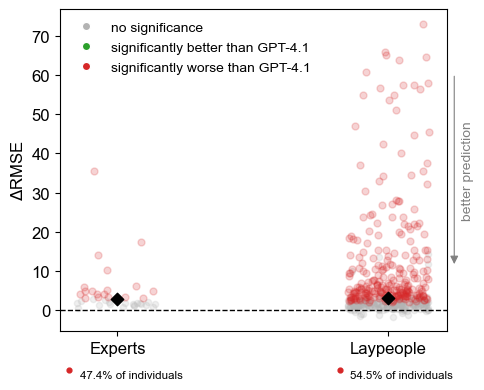

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_delta_rmse_individuals_simple(
    df_base_se,
    {"Laypeople": df_laypeople_se, "Experts": df_experts_se},
    baseline_col="baseline",
    ax=ax,
    n_boot=500
)
plt.tight_layout()
plt.show()

# Fig. 4: Individual and collection RMSE

In [19]:
df_individual_se = pd.read_csv(base_dir + 'output/se_individual_report.csv', index_col=0)
df_collection_se = pd.read_csv(base_dir + 'output/se_collection_report.csv', index_col=0)
#df_all_se = pd.read_csv(base_dir + 'output/se_all_rag.csv', index_col=0)

In [275]:
df_collection_se = pd.concat([df_collection_se, df_all_se]) # include all paper prediction

In [21]:
import numpy as np

def delta_rmse(se_model, se_base):
    """RMSE(model) - RMSE(baseline)."""
    rmse_model = np.sqrt(se_model.mean())
    rmse_base  = np.sqrt(se_base.mean())
    return rmse_model - rmse_base

def bootstrap_delta_rmse(se_model, se_base, n_boot=5000, rng=None):
    """
    Paired bootstrap over designs for one model, matching your original code:
    - resample designs with replacement
    - compute ΔRMSE for each resample
    - return (bootstrapped mean, 2.5%, 97.5%).
    """
    if rng is None:
        rng = np.random.default_rng()
    n = len(se_model)
    boot_vals = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_vals[b] = delta_rmse(se_model[idx], se_base[idx])
    lo, hi = np.percentile(boot_vals, [2.5, 97.5])
    return boot_vals.mean(), lo, hi

def compute_paper_deltas(df_base_se, df_individual_se,
                         baseline_col='baseline',
                         n_boot=5000, seed=42):
    """
    Compute per-paper ΔRMSE and 95% CIs using the same bootstrap
    as your original snippet.
    """
    baseline_se = df_base_se[baseline_col].values
    n_papers = df_individual_se.shape[0]

    rng = np.random.default_rng(seed)
    delta_est = np.empty(n_papers)
    ci_low = np.empty(n_papers)
    ci_high = np.empty(n_papers)

    for i in range(n_papers):
        se_paper = df_individual_se.iloc[i].values
        est, lo, hi = bootstrap_delta_rmse(
            se_paper, baseline_se, n_boot=n_boot, rng=rng
        )
        delta_est[i] = est
        ci_low[i] = lo
        ci_high[i] = hi

    return delta_est, ci_low, ci_high

In [22]:
import numpy as np

def random_effects_meta_from_cis(delta_est, ci_low, ci_high):
    """
    Random-effects meta-analysis over papers using per-paper 95% CIs.

    Parameters
    ----------
    delta_est : array-like, shape (N,)
        Per-paper point estimates (e.g., ΔRMSE for each paper).

    ci_low : array-like, shape (N,)
        Lower bound of the 95% CI for each paper.

    ci_high : array-like, shape (N,)
        Upper bound of the 95% CI for each paper.

    Returns
    -------
    mu_RE : float
        Pooled random-effects estimate (mean ΔRMSE across papers).

    ci_lo_RE : float
        Lower bound of the 95% CI for the pooled estimate.

    ci_hi_RE : float
        Upper bound of the 95% CI for the pooled estimate.

    tau2 : float
        Estimated between-paper variance (DerSimonian–Laird).
    """
    delta_est = np.asarray(delta_est, dtype=float)
    ci_low = np.asarray(ci_low, dtype=float)
    ci_high = np.asarray(ci_high, dtype=float)

    # Approximate per-paper SE from CI width
    # CI ≈ estimate ± 1.96 * SE  =>  SE ≈ (hi - lo) / (2 * 1.96)
    se = (ci_high - ci_low) / (2.0 * 1.96)
    v = se**2  # sampling variance per paper

    # Keep only finite, positive-variance papers
    mask = np.isfinite(delta_est) & np.isfinite(v) & (v > 0)
    y = delta_est[mask]
    v = v[mask]

    if len(y) < 2:
        raise ValueError("Not enough valid papers to run random-effects meta-analysis.")

    # Fixed-effect weights
    w = 1.0 / v
    mu_FE = np.sum(w * y) / np.sum(w)

    # DerSimonian–Laird between-paper variance tau^2
    Q = np.sum(w * (y - mu_FE)**2)
    df = len(y) - 1
    c = np.sum(w) - (np.sum(w**2) / np.sum(w))
    if c <= 0:
        tau2 = 0.0
    else:
        tau2 = max(0.0, (Q - df) / c)

    # Random-effects weights
    w_star = 1.0 / (v + tau2)

    # Pooled random-effects estimate
    mu_RE = np.sum(w_star * y) / np.sum(w_star)
    var_mu_RE = 1.0 / np.sum(w_star)
    se_mu_RE = np.sqrt(var_mu_RE)

    # 95% CI (normal approx)
    ci_lo_RE = mu_RE - 1.96 * se_mu_RE
    ci_hi_RE = mu_RE + 1.96 * se_mu_RE

    return mu_RE, ci_lo_RE, ci_hi_RE, tau2

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_delta_rmse_forest(
    df_base_se,
    df_individual_se,
    baseline_col='baseline',
    n_boot_paper=2000,
    n_boot_mean=3000,
    ax=None,
):
    """
    Plot per-paper ΔRMSE (paper − baseline) with CIs and a summary
    'Average across papers' point.

    Parameters
    ----------
    df_base_se : pd.DataFrame
        Rows = designs, must contain a column `baseline_col` with squared errors
        (SE) for the baseline predictor for each design.

    df_individual_se : pd.DataFrame
        Rows = individual papers (or models), columns = designs.
        Each cell is the squared error for that paper on that design.
        Columns must be aligned with the rows of df_base_se (same order).

    baseline_col : str
        Name of the baseline SE column in df_base_se.

    n_boot_paper : int
        Number of bootstrap draws per paper for the per-paper CIs.

    n_boot_mean : int
        Number of hierarchical bootstrap draws for the 'average across papers' CI.

    ax : matplotlib.axes.Axes or None
        If provided, plot into this axes; otherwise create a new figure+axes.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes with the plot.
    """

    # --- Extract squared errors and clean for non-finite values ---
    se_papers = df_individual_se.values           # shape (N, J)
    baseline_se = df_base_se[baseline_col].values # shape (J,)

    N, J = se_papers.shape

    # Keep only designs where baseline and all paper SEs are finite
    finite_designs = np.isfinite(baseline_se) & np.all(np.isfinite(se_papers), axis=0)
    se_papers = se_papers[:, finite_designs]
    baseline_se = baseline_se[finite_designs]

    N, J = se_papers.shape
    rng = np.random.default_rng(42)

    # --- Helper for per-paper ΔRMSE + CI (bootstrap over designs) ---
    def bootstrap_delta_rmse_single(se_model, se_base, n_boot, rng):
        """
        Paired bootstrap over designs for a single paper.
        Returns (est, lo, hi) for ΔRMSE.
        """
        # Point estimate
        rmse_model = np.sqrt(np.nanmean(se_model))
        rmse_base = np.sqrt(np.nanmean(se_base))
        est = rmse_model - rmse_base

        n = len(se_base)
        boot_vals = np.empty(n_boot)
        for b in range(n_boot):
            idx = rng.integers(0, n, size=n)
            se_m = se_model[idx]
            se_b = se_base[idx]
            rmse_m = np.sqrt(np.nanmean(se_m))
            rmse_b = np.sqrt(np.nanmean(se_b))
            boot_vals[b] = rmse_m - rmse_b

        lo, hi = np.percentile(boot_vals, [2.5, 97.5])
        return est, lo, hi

    # --- Per-paper ΔRMSE and CIs ---
    delta_est = np.empty(N)
    ci_low = np.empty(N)
    ci_high = np.empty(N)

    for i in range(N):
        est, lo, hi = bootstrap_delta_rmse_single(
            se_papers[i, :], baseline_se, n_boot_paper, rng
        )
        delta_est[i] = est
        ci_low[i] = lo
        ci_high[i] = hi

    # Sort papers by ΔRMSE
    order = np.argsort(delta_est)
    delta_sorted = delta_est[order]
    ci_low_sorted = ci_low[order]
    ci_high_sorted = ci_high[order]

    # Significance
    sig_better = ci_high_sorted < 0       # CI entirely below 0
    sig_worse = ci_low_sorted > 0         # CI entirely above 0
    sig_none = ~(sig_better | sig_worse)

    n_better = int(sig_better.sum())
    n_worse = int(sig_worse.sum())
    n_none = int(sig_none.sum())

    pct_better = 100 * n_better / N
    pct_worse = 100 * n_worse / N
    pct_none = 100 * n_none / N

    # --- Hierarchical bootstrap for mean ΔRMSE across papers ---
    # Per-paper ΔRMSE on the original cleaned test set
    rmse_papers = np.sqrt(np.nanmean(se_papers, axis=1))    # (N,)
    rmse_baseline = np.sqrt(np.nanmean(baseline_se))        # scalar
    delta_per_paper = rmse_papers - rmse_baseline           # (N,)
    summary_est = delta_per_paper.mean()

    boot_means = np.empty(n_boot_mean)
    for b in range(n_boot_mean):
        # Resample designs with replacement
        idx_designs = rng.integers(0, J, size=J)
        se_papers_boot = se_papers[:, idx_designs]       # (N, J)
        baseline_se_boot = baseline_se[idx_designs]      # (J,)

        rmse_papers_boot = np.sqrt(np.nanmean(se_papers_boot, axis=1))  # (N,)
        rmse_baseline_boot = np.sqrt(np.nanmean(baseline_se_boot))      # scalar
        delta_papers_boot = rmse_papers_boot - rmse_baseline_boot       # (N,)

        finite = np.isfinite(delta_papers_boot)
        if not finite.any():
            boot_means[b] = np.nan
            continue

        # Resample papers with replacement and average
        idx_papers = rng.integers(0, finite.sum(), size=finite.sum())
        boot_means[b] = delta_papers_boot[finite][idx_papers].mean()

    boot_means = boot_means[np.isfinite(boot_means)]
    summary_lo, summary_hi = np.percentile(boot_means, [2.5, 97.5])

    # --- Plotting ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3.5))
    else:
        fig = ax.figure

    x_papers = np.arange(N)

    # Non-significant
    for x, y, lo, hi in zip(
        x_papers[sig_none],
        delta_sorted[sig_none],
        ci_low_sorted[sig_none],
        ci_high_sorted[sig_none],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='0.7', ecolor='0.7',
            capsize=2, linewidth=0.5, markersize=3,
            alpha=0.2, linestyle='none'
        )

    # Significantly better (green)
    for x, y, lo, hi in zip(
        x_papers[sig_better],
        delta_sorted[sig_better],
        ci_low_sorted[sig_better],
        ci_high_sorted[sig_better],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='tab:green', ecolor='tab:green',
            capsize=2, linewidth=1.0, markersize=4,
            alpha=0.2, linestyle='none'
        )

    # Significantly worse (red)
    for x, y, lo, hi in zip(
        x_papers[sig_worse],
        delta_sorted[sig_worse],
        ci_low_sorted[sig_worse],
        ci_high_sorted[sig_worse],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='tab:red', ecolor='tab:red',
            capsize=2, linewidth=1.0, markersize=4,
            alpha=0.2, linestyle='none'
        )

    # Summary point (mean across papers) – solid black
    gap = max(20, int(N * 0.02))
    x_summary = N + gap
    summary_yerr = [[summary_est - summary_lo], [summary_hi - summary_est]]

    ax.errorbar(
        x_summary, summary_est, yerr=summary_yerr,
        fmt='s', color='black', ecolor='black',
        capsize=4, linewidth=1.5, markersize=5,
        linestyle='none'
    )

    # Baseline line
    ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

    # Axes
    ax.set_ylabel(r'$\Delta$RMSE')
    ax.set_xlabel("Augmented article (full text)")
    #ax.set_xticks([x_summary])
    ax.set_xlim(-5, x_summary + 15)

    # Legend with counts + percentages
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               label=f'Significantly improves prediction (n = {n_better}, {pct_better:.1f}%)',
               markerfacecolor='tab:green', markersize=5),
        Line2D([0], [0], marker='o', color='w',
               label=f'No significance (n = {n_none}, {pct_none:.1f}%)',
               markerfacecolor='0.7', markersize=5),
        Line2D([0], [0], marker='o', color='w',
               label=f'Significantly worsens prediction (n = {n_worse}, {pct_worse:.1f}%)',
               markerfacecolor='tab:red', markersize=5),
        Line2D([0], [0], marker='s', color='w',
               label='Average across papers',
               markerfacecolor='black', markersize=5),
    ]
    ax.legend(handles=legend_elements, loc='upper left',
              frameon=False, fontsize='small')

    # Leave space for arrow on the right
    fig.subplots_adjust(right=0.88)

    # Arrow + text just outside the right axis
    x_arrow = 1.02  # slightly to the right of the frame
    y_top, y_bottom = 0.8, 0.2

    ax.annotate(
        '', xy=(x_arrow, y_bottom), xytext=(x_arrow, y_top),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(
            arrowstyle='-|>',
            color='0.5',
            lw=0.8
        )
    )

    ax.text(
        x_arrow + 0.02, (y_top + y_bottom) / 2,
        'better prediction',
        color='0.5',
        rotation=90,
        va='center',
        ha='left',
        fontsize='small',
        transform=ax.transAxes
    )

    return ax

In [24]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_delta_rmse_forest(delta_est, ci_low, ci_high, ax=None):
    """
    Plot per-paper ΔRMSE forest plot + random-effects pooled mean.

    Parameters
    ----------
    delta_est, ci_low, ci_high : np.ndarray
        Per-paper ΔRMSE and 95% CIs (from compute_paper_deltas).

    ax : matplotlib.axes.Axes or None
        If provided, draw on this axes. Otherwise create a new one.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes containing the plot.
    """
    delta_est = np.asarray(delta_est)
    ci_low = np.asarray(ci_low)
    ci_high = np.asarray(ci_high)

    n_papers = len(delta_est)

    # Sort by ΔRMSE
    order = np.argsort(delta_est)
    delta_sorted = delta_est[order]
    ci_low_sorted = ci_low[order]
    ci_high_sorted = ci_high[order]

    # Significance
    sig_better = ci_high_sorted < 0
    sig_worse  = ci_low_sorted > 0
    sig_none   = ~(sig_better | sig_worse)

    n_better = int(sig_better.sum())
    n_worse  = int(sig_worse.sum())
    n_none   = int(sig_none.sum())

    pct_better = 100 * n_better / n_papers
    pct_worse  = 100 * n_worse  / n_papers
    pct_none   = 100 * n_none   / n_papers

    # Meta-analytic pooled mean + CI
    summary_est, summary_lo, summary_hi, tau2 = random_effects_meta_from_cis(
        delta_est, ci_low, ci_high
    )

    # Plotting
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3.5))
    else:
        fig = ax.figure

    x_papers = np.arange(n_papers)

    # Non-significant
    for x, y, lo, hi in zip(
        x_papers[sig_none],
        delta_sorted[sig_none],
        ci_low_sorted[sig_none],
        ci_high_sorted[sig_none],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='0.7', ecolor='0.7',
            capsize=2, linewidth=0.5, markersize=3,
            alpha=0.2, linestyle='none'
        )

    # Significantly better (green)
    for x, y, lo, hi in zip(
        x_papers[sig_better],
        delta_sorted[sig_better],
        ci_low_sorted[sig_better],
        ci_high_sorted[sig_better],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='tab:green', ecolor='tab:green',
            capsize=2, linewidth=1.0, markersize=4,
            alpha=0.2, linestyle='none'
        )

    # Significantly worse (red)
    for x, y, lo, hi in zip(
        x_papers[sig_worse],
        delta_sorted[sig_worse],
        ci_low_sorted[sig_worse],
        ci_high_sorted[sig_worse],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='tab:red', ecolor='tab:red',
            capsize=2, linewidth=1.0, markersize=4,
            alpha=0.2, linestyle='none'
        )

    # Summary point (meta-analytic pooled mean)
    gap = max(20, int(n_papers * 0.02))
    x_summary = n_papers + gap
    summary_yerr = [[summary_est - summary_lo], [summary_hi - summary_est]]

    ax.errorbar(
        x_summary, summary_est, yerr=summary_yerr,
        fmt='s', color='black', ecolor='black',
        capsize=4, linewidth=1.5, markersize=5,
        linestyle='none'
    )

    # Baseline line
    ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

    # Axes
    ax.set_ylabel(r'$\Delta$RMSE')
    ax.set_xlabel("Augmented article (full text)")
    ax.set_xticks([])
    ax.set_xlim(-5, x_summary + 15)

    # Legend with counts + percentages
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               label=f'Significantly improves prediction (n = {n_better}, {pct_better:.1f}%)',
               markerfacecolor='tab:green', markersize=5),
        Line2D([0], [0], marker='o', color='w',
               label=f'No significance (n = {n_none}, {pct_none:.1f}%)',
               markerfacecolor='0.7', markersize=5),
        Line2D([0], [0], marker='o', color='w',
               label=f'Significantly worsens prediction (n = {n_worse}, {pct_worse:.1f}%)',
               markerfacecolor='tab:red', markersize=5),
        Line2D([0], [0], marker='s', color='w',
               label='Average across papers',
               markerfacecolor='black', markersize=5),
    ]
    ax.legend(handles=legend_elements, loc='upper left',
              frameon=False, fontsize='small')

    # Leave space for arrow
    fig.subplots_adjust(right=0.88)

    # Arrow + label just outside right axis
    x_arrow = 1.02  # slightly to the right of the frame
    y_top, y_bottom = 0.8, 0.2

    ax.annotate(
        '', xy=(x_arrow, y_bottom), xytext=(x_arrow, y_top),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(
            arrowstyle='-|>',
            color='0.5',
            lw=0.8
        )
    )

    ax.text(
        x_arrow + 0.02, (y_top + y_bottom) / 2,
        'better prediction',
        color='0.5',
        rotation=90,
        va='center',
        ha='left',
        fontsize='small',
        transform=ax.transAxes
    )

    return ax

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_delta_rmse_forest(delta_est, ci_low, ci_high, ax=None):
    """
    Plot per-paper ΔRMSE forest + random-effects pooled mean.

    Parameters
    ----------
    delta_est, ci_low, ci_high : np.ndarray
        Per-paper ΔRMSE and 95% CIs (from compute_paper_deltas).

    ax : matplotlib.axes.Axes or None
        If provided, draw on this axes. Otherwise create a new one.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes containing the plot.
    """
    delta_est = np.asarray(delta_est)
    ci_low = np.asarray(ci_low)
    ci_high = np.asarray(ci_high)

    n_papers = len(delta_est)

    # --- Sort papers by ΔRMSE ---
    order = np.argsort(delta_est)
    delta_sorted = delta_est[order]
    ci_low_sorted = ci_low[order]
    ci_high_sorted = ci_high[order]

    # --- Significance ---
    sig_better = ci_high_sorted < 0
    sig_worse  = ci_low_sorted > 0
    sig_none   = ~(sig_better | sig_worse)

    n_better = int(sig_better.sum())
    n_worse  = int(sig_worse.sum())
    n_none   = int(sig_none.sum())

    pct_better = 100 * n_better / n_papers
    pct_worse  = 100 * n_worse  / n_papers
    pct_none   = 100 * n_none   / n_papers

    # --- Random-effects meta-analysis for pooled mean ---
    def random_effects_meta_from_cis(delta_est, ci_low, ci_high):
        delta_est = np.asarray(delta_est, dtype=float)
        ci_low = np.asarray(ci_low, dtype=float)
        ci_high = np.asarray(ci_high, dtype=float)

        # Approximate SE from 95% CI width
        se = (ci_high - ci_low) / (2.0 * 1.96)
        v = se**2

        mask = np.isfinite(delta_est) & np.isfinite(v) & (v > 0)
        y = delta_est[mask]
        v = v[mask]

        if len(y) < 2:
            raise ValueError("Not enough valid papers for random-effects meta-analysis.")

        # Fixed-effect weights
        w = 1.0 / v
        mu_FE = np.sum(w * y) / np.sum(w)

        # DerSimonian–Laird tau^2
        Q = np.sum(w * (y - mu_FE)**2)
        df = len(y) - 1
        c = np.sum(w) - (np.sum(w**2) / np.sum(w))
        if c <= 0:
            tau2 = 0.0
        else:
            tau2 = max(0.0, (Q - df) / c)

        # Random-effects weights
        w_star = 1.0 / (v + tau2)
        mu_RE = np.sum(w_star * y) / np.sum(w_star)
        var_mu_RE = 1.0 / np.sum(w_star)
        se_mu_RE = np.sqrt(var_mu_RE)

        ci_lo_RE = mu_RE - 1.96 * se_mu_RE
        ci_hi_RE = mu_RE + 1.96 * se_mu_RE

        return mu_RE, ci_lo_RE, ci_hi_RE, tau2

    summary_est, summary_lo, summary_hi, tau2 = random_effects_meta_from_cis(
        delta_est, ci_low, ci_high
    )

    # --- Plotting ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3.5))
    else:
        fig = ax.figure

    x_papers = np.arange(n_papers)

    # Non-significant (grey)
    for x, y, lo, hi in zip(
        x_papers[sig_none],
        delta_sorted[sig_none],
        ci_low_sorted[sig_none],
        ci_high_sorted[sig_none],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='0.7', ecolor='0.7',
            capsize=2, linewidth=0.5, markersize=3,
            alpha=0.2, linestyle='none'
        )

    # Significantly better (green)
    for x, y, lo, hi in zip(
        x_papers[sig_better],
        delta_sorted[sig_better],
        ci_low_sorted[sig_better],
        ci_high_sorted[sig_better],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='tab:green', ecolor='tab:green',
            capsize=2, linewidth=1.0, markersize=4,
            alpha=0.2, linestyle='none'
        )

    # Significantly worse (red)
    for x, y, lo, hi in zip(
        x_papers[sig_worse],
        delta_sorted[sig_worse],
        ci_low_sorted[sig_worse],
        ci_high_sorted[sig_worse],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='tab:red', ecolor='tab:red',
            capsize=2, linewidth=1.0, markersize=4,
            alpha=0.2, linestyle='none'
        )

    # Summary point (meta-analytic pooled mean), solid black
    gap = min(40, int(n_papers * 0.02))  # more space on the right
    x_summary = n_papers + gap
    summary_yerr = [[summary_est - summary_lo], [summary_hi - summary_est]]

    ax.errorbar(
        x_summary, summary_est, yerr=summary_yerr,
        fmt='s', color='black', ecolor='black',
        capsize=4, linewidth=1.5, markersize=5,
        linestyle='none'
    )

    # Thicker vertical separator line between individual papers and mean
    x_sep = n_papers#(n_papers - 1 + x_summary) / 2.0
    ax.axvline(x_sep, color='0.6', linestyle='-', linewidth=1.5)

    # Baseline horizontal line
    ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

    # Axes labels and ticks
    ax.set_ylabel(r'$\Delta$RMSE with 95% CIs')
    ax.set_xlabel("Augmented article (full text)")
    ax.set_xticks([])

    # Expand x-limits a bit to give the mean + arrow more breathing room
    ax.set_xlim(-5, x_summary + gap)

    # --- Legend with only the three significance categories ---
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               label=f'Significantly improves prediction (n = {n_better}, {pct_better:.1f}%)',
               markerfacecolor='tab:green', markersize=5),
        Line2D([0], [0], marker='o', color='w',
               label=f'No significance (n = {n_none}, {pct_none:.1f}%)',
               markerfacecolor='0.7', markersize=5),
        Line2D([0], [0], marker='o', color='w',
               label=f'Significantly worsens prediction (n = {n_worse}, {pct_worse:.1f}%)',
               markerfacecolor='tab:red', markersize=5),
    ]
    ax.legend(handles=legend_elements, loc='upper left',
              frameon=False, fontsize='small')

    # Leave space for arrow and average text on the right
    fig.subplots_adjust(right=0.86)

    # Arrow + label just outside the right axis
    x_arrow = 1.02  # slightly to the right of the frame
    y_top, y_bottom = 0.8, 0.2

    ax.annotate(
        '', xy=(x_arrow, y_bottom), xytext=(x_arrow, y_top),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(
            arrowstyle='-|>',
            color='0.5',
            lw=0.8
        )
    )

    ax.text(
        x_arrow + 0.02, (y_top + y_bottom) / 2,
        'better prediction',
        color='0.5',
        rotation=90,
        va='center',
        ha='left',
        fontsize='small',
        transform=ax.transAxes
    )

    # --- Rotated text label next to the average point ---
    # --- Rotated text label next to the average point ---
    mean_str = f"{summary_est:.2f}"
    ci_lo_str = f"{summary_lo:.2f}"
    ci_hi_str = f"{summary_hi:.2f}"
    avg_text = f"Average: {mean_str} ({ci_lo_str} to {ci_hi_str})"

    # Put the label midway between the separator line and the right edge,
    # anchored at the top so it doesn’t overlap the bar, and a bit smaller.
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    x_text = x_sep + gap #(x_sep + xmax) / 2.0   # middle between separation line and right edge
    y_text = ymax - 1                   # top of the plotting area

    ax.text(
        x_text, y_text,
        avg_text,
        rotation=90,
        va='top',      # end of the text touches the top
        ha='center',
        fontsize='x-small'
    )

    return ax

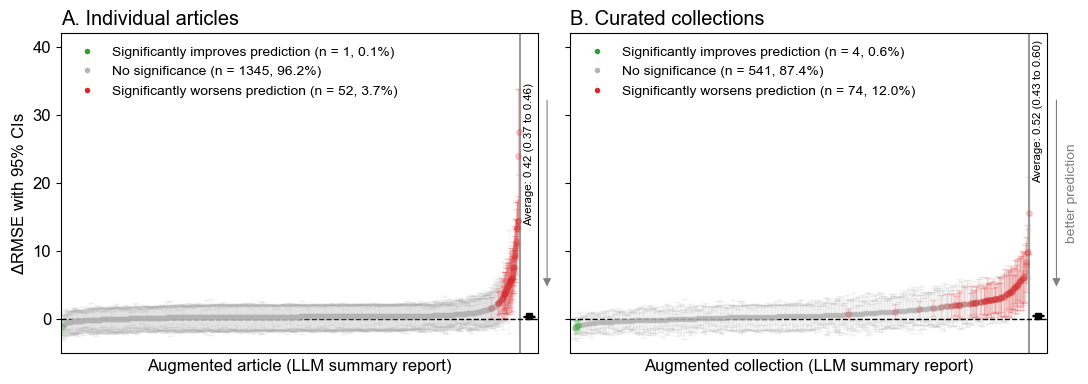

In [30]:
from matplotlib.patches import FancyArrowPatch

# 1) Compute per-predictor ΔRMSE and CIs
delta_art, ci_lo_art, ci_hi_art = compute_paper_deltas(
    df_base_se, df_individual_se,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

delta_coll, ci_lo_coll, ci_hi_coll = compute_paper_deltas(
    df_base_se, df_collection_se,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

# 2) Two subplots side by side with shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

# ----- Left: individual articles -----
ax1 = axes[0]
plot_delta_rmse_forest(delta_art, ci_lo_art, ci_hi_art, ax=ax1)
ax1.set_ylim(-5, 42)
ax1.set_title("A. Individual articles", loc="left")

# Remove the arrow + "better prediction" label from the left panel
for txt in list(ax1.texts):
    if txt.get_text() == 'better prediction':
        txt.remove()

for patch in list(ax1.patches):
    if isinstance(patch, FancyArrowPatch):
        patch.remove()

# Keep y-label on the left as is
ax1.set_xlabel("Augmented article (LLM summary report)")

# ----- Right: curated collections -----
ax2 = axes[1]
plot_delta_rmse_forest(delta_coll, ci_lo_coll, ci_hi_coll, ax=ax2)
ax2.set_ylim(-5, 42)
ax2.set_title("B. Curated collections", loc='left')
ax2.set_ylabel('')  # keep y-label only on left
ax2.set_xlabel("Augmented collection (RAG)")

# === Highlight the 'ALL' collection ===
# Find its original row index in df_collection_se
#all_idx = df_collection_se.index.get_loc('ALL')

# Find its x-position after sorting by ΔRMSE (same sort as inside the plot function)
order_coll = np.argsort(delta_coll)
#x_all = np.where(order_coll == all_idx)[0][0]

# Vertical line at that x, plus a small rotated label
#ax2.axvline(x_all, color='black', linestyle=':', linewidth=1)

#ymin, ymax = ax2.get_ylim()
#ax2.text(
#    x_all - 10,
#    ymax - 1,                     # just below the top
#    'all 1,398 papers',
#    rotation=90,
#    va='top',
#    ha='center',
#    fontsize='x-small'
#)

# Share y-axis: remove duplicate y-label on the right
ax2.set_ylabel('')
ax2.set_xlabel("Augmented collection (LLM summary report)")

plt.tight_layout()
plt.show()

In [262]:
# 1) Compute per-paper ΔRMSE and CIs (bootstrap over designs)
delta_est, ci_low, ci_high = compute_paper_deltas(
    df_base_se, df_individual_se,
    baseline_col='baseline',
    n_boot=500,
    seed=42,
)



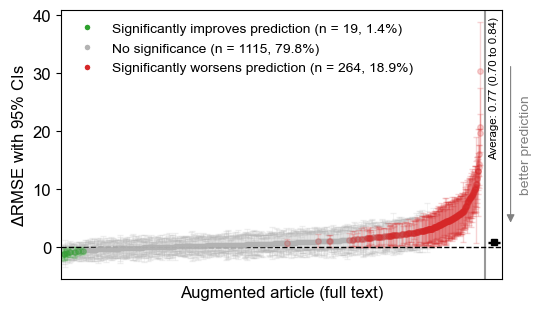

In [263]:
# 2) Plot the forest with meta-analytic pooled mean
ax = plot_delta_rmse_forest(delta_est, ci_low, ci_high)
plt.show()

In [260]:
# 1) Compute per-paper ΔRMSE and CIs (bootstrap over designs)
delta_est, ci_low, ci_high = compute_paper_deltas(
    df_base_se, df_collection_se,
    baseline_col='baseline',
    n_boot=500,
    seed=42,
)



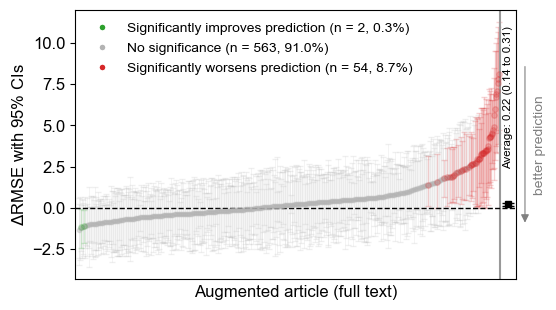

In [261]:
# 2) Plot the forest with meta-analytic pooled mean
ax = plot_delta_rmse_forest(delta_est, ci_low, ci_high)
plt.show()

In [ ]:
mu_RE, mu_lo, mu_hi, tau2 = random_effects_meta_from_cis(delta_est, ci_low, ci_high)

summary_est = mu_RE
summary_lo  = mu_lo
summary_hi  = mu_hi

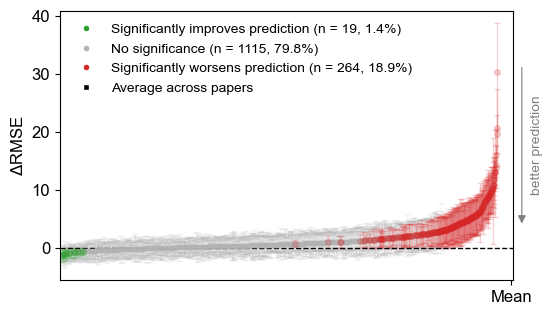

In [202]:
# 1) Compute per-paper deltas using your bootstrap semantics
delta_est, ci_low, ci_high = compute_paper_deltas(
    df_base_se, df_individual_se,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

# 2) Plot using those deltas and CIs
ax = plot_delta_rmse_forest_from_deltas(
    df_base_se, df_individual_se,
    delta_est, ci_low, ci_high,
    baseline_col='baseline',
    n_boot_mean=1000,
)
plt.show()

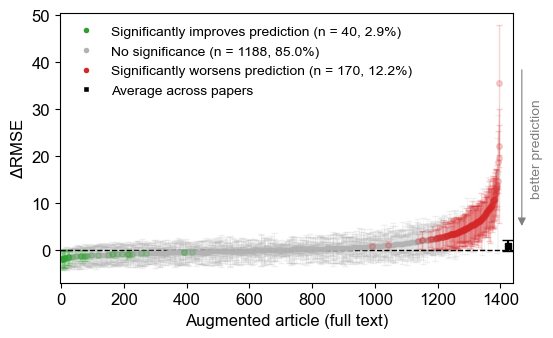

In [198]:
ax = plot_delta_rmse_forest(df_base_se, df_individual_se, n_boot_paper=1000)
plt.show()

In [128]:
import numpy as np
import matplotlib.pyplot as plt

# --- Inputs ---
# df_base_se: rows = 20 config pairs, column 'baseline' = squared error per config
# df_individual_se: rows = papers (N), columns = same 20 configs (squared errors)

baseline_se = df_base_se['baseline'].values  # shape (20,)
rmse_base = np.sqrt(baseline_se.mean())

n_papers = df_individual_se.shape[0]
n_pairs = baseline_se.shape[0]
n_boot = 500
rng = np.random.default_rng(seed=42)

def delta_rmse(se_model, se_base):
    """RMSE(model) - RMSE(baseline) over the 20 configs."""
    rmse_model = np.sqrt(se_model.mean())
    rmse_base  = np.sqrt(se_base.mean())
    return rmse_model - rmse_base

def bootstrap_delta_rmse(se_model, se_base, n_boot=5000, rng=None):
    """Paired bootstrap over configs to get ΔRMSE + 95% CI for one model."""
    if rng is None:
        rng = np.random.default_rng()
    n = len(se_model)
    boot_vals = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)  # resample config indices
        boot_vals[b] = delta_rmse(se_model[idx], se_base[idx])
    lo, hi = np.percentile(boot_vals, [2.5, 97.5])
    return boot_vals.mean(), lo, hi

# --- Compute ΔRMSE and CIs per paper ---

delta_est = np.empty(n_papers)
ci_low = np.empty(n_papers)
ci_high = np.empty(n_papers)

for i in range(n_papers):
    se_paper = df_individual_se.iloc[i].values  # squared errors for paper i across 20 configs
    est, lo, hi = bootstrap_delta_rmse(se_paper, baseline_se, n_boot=n_boot, rng=rng)
    delta_est[i] = est
    ci_low[i] = lo
    ci_high[i] = hi

# Sort papers by ΔRMSE (best -> worst)
order = np.argsort(delta_est)
delta_est_sorted = delta_est[order]
ci_low_sorted = ci_low[order]
ci_high_sorted = ci_high[order]

# Determine significance for color-coding
sig_better = ci_high_sorted < 0    # CI entirely below 0
sig_worse  = ci_low_sorted > 0     # CI entirely above 0
sig_none   = ~(sig_better | sig_worse)

colors = np.full(n_papers, '0.7', dtype=object)  # default grey
colors[sig_better] = 'tab:green'
colors[sig_worse]  = 'tab:red'

# --- Summary point: "average paper" at far right ---

# One natural summary: average squared error across papers for each config,
# then compute ΔRMSE vs baseline.
mean_se_per_config = df_individual_se.mean(axis=0).values  # shape (20,)
summary_est, summary_lo, summary_hi = bootstrap_delta_rmse(
    mean_se_per_config, baseline_se, n_boot=n_boot, rng=rng
)

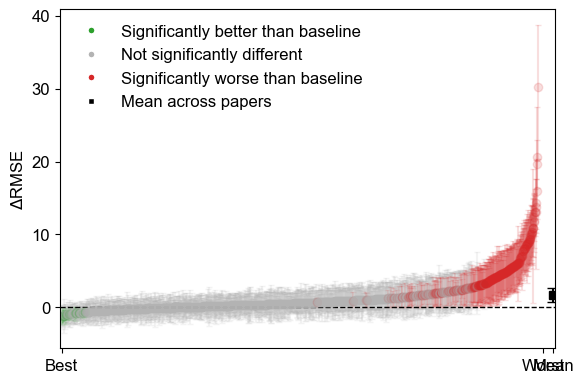

In [129]:
# --- Plot ---

fig, ax = plt.subplots(figsize=(6, 4))

# x positions for individual papers
x_papers = np.arange(n_papers)

# yerr for each paper
yerr_lower = delta_est_sorted - ci_low_sorted
yerr_upper = ci_high_sorted - delta_est_sorted

# Plot each paper as point+error bar, colored by significance
for x, y, lo, hi, c in zip(
    x_papers, delta_est_sorted, yerr_lower, yerr_upper, colors
):
    ax.errorbar(
        x, y,
        yerr=[[lo], [hi]],
        fmt='o',
        color=c,
        ecolor=c,
        capsize=2,
        linestyle='none',
        alpha=0.15
    )

# Add summary point at the right
gap = max(20, n_papers * 0.02)  # small visual gap
x_summary = n_papers + gap

summary_yerr = [[summary_est - summary_lo], [summary_hi - summary_est]]
ax.errorbar(
    x_summary, summary_est, yerr=summary_yerr,
    fmt='s', color='black', ecolor='black',
    capsize=4, linestyle='none', label='Mean across papers'
)

# Horizontal line at 0 (no change)
ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

# Axes + labels
ax.set_ylabel(r'$\Delta$RMSE')
ax.set_xlim(-5, x_summary + 5)

# We don't label every paper on x (too many); just mark the summary
ax.set_xticks([0, x_papers[-1], x_summary])
ax.set_xticklabels(['Best', 'Worst', 'Mean'])

# Legend for significance colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Significantly better than baseline',
           markerfacecolor='tab:green', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label='Not significantly different',
           markerfacecolor='0.7', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label='Significantly worse than baseline',
           markerfacecolor='tab:red', markersize=5),
    Line2D([0], [0], marker='s', color='w',
           label='Mean across papers',
           markerfacecolor='black', markersize=5),
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

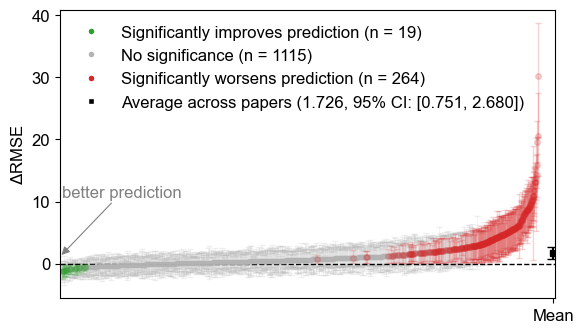

In [134]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

baseline_se = df_base_se['baseline'].values
n_papers = df_individual_se.shape[0]
n_pairs = baseline_se.shape[0]
n_boot = 500
rng = np.random.default_rng(seed=42)

def delta_rmse(se_model, se_base):
    rmse_model = np.sqrt(se_model.mean())
    rmse_base  = np.sqrt(se_base.mean())
    return rmse_model - rmse_base

def bootstrap_delta_rmse(se_model, se_base, n_boot=5000, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n = len(se_model)
    boot_vals = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_vals[b] = delta_rmse(se_model[idx], se_base[idx])
    lo, hi = np.percentile(boot_vals, [2.5, 97.5])
    return boot_vals.mean(), lo, hi

# --- ΔRMSE + CIs per paper ---

delta_est = np.empty(n_papers)
ci_low = np.empty(n_papers)
ci_high = np.empty(n_papers)

for i in range(n_papers):
    se_paper = df_individual_se.iloc[i].values
    est, lo, hi = bootstrap_delta_rmse(se_paper, baseline_se, n_boot=n_boot, rng=rng)
    delta_est[i] = est
    ci_low[i] = lo
    ci_high[i] = hi

# Sort by ΔRMSE
order = np.argsort(delta_est)
delta_est_sorted = delta_est[order]
ci_low_sorted = ci_low[order]
ci_high_sorted = ci_high[order]

# Significance masks
sig_better = ci_high_sorted < 0
sig_worse  = ci_low_sorted > 0
sig_none   = ~(sig_better | sig_worse)

n_better = int(sig_better.sum())
n_worse  = int(sig_worse.sum())
n_none   = int(sig_none.sum())

# Summary point: mean across papers (per config, then ΔRMSE)
mean_se_per_config = df_individual_se.mean(axis=0).values
summary_est, summary_lo, summary_hi = bootstrap_delta_rmse(
    mean_se_per_config, baseline_se, n_boot=n_boot, rng=rng
)

# --- Plot ---

fig, ax = plt.subplots(figsize=(6, 3.5))

x_papers = np.arange(n_papers)

# non-significant: light grey, alpha=0.2, with error bars
for x, y, lo, hi in zip(
    x_papers[sig_none],
    delta_est_sorted[sig_none],
    ci_low_sorted[sig_none],
    ci_high_sorted[sig_none],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='0.7', ecolor='0.7',
        capsize=2, linewidth=0.5, markersize=3,
        alpha=0.2
    )

# significantly better: green
for x, y, lo, hi in zip(
    x_papers[sig_better],
    delta_est_sorted[sig_better],
    ci_low_sorted[sig_better],
    ci_high_sorted[sig_better],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='tab:green', ecolor='tab:green',
        capsize=2, linewidth=1.0, markersize=4,
        alpha=0.2
    )

# significantly worse: red
for x, y, lo, hi in zip(
    x_papers[sig_worse],
    delta_est_sorted[sig_worse],
    ci_low_sorted[sig_worse],
    ci_high_sorted[sig_worse],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='tab:red', ecolor='tab:red',
        capsize=2, linewidth=1.0, markersize=4,
        alpha=0.2
    )

# summary point at the right
gap = max(20, int(n_papers * 0.02))
x_summary = n_papers + gap
summary_yerr = [[summary_est - summary_lo], [summary_hi - summary_est]]

ax.errorbar(
    x_summary, summary_est, yerr=summary_yerr,
    fmt='s', color='black', ecolor='black',
    capsize=4, linewidth=1.5, markersize=5
)

# horizontal baseline
ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

# y-label
ax.set_ylabel(r'$\Delta$RMSE')

# x-ticks: only label the summary (no "Best"/"Worst")
ax.set_xticks([x_summary])
ax.set_xticklabels(['Mean'])

# optional: tighten x-limits
ax.set_xlim(-5, x_summary + 5)

# downward arrow + "better prediction" text in grey
ymin, ymax = ax.get_ylim()
# place text slightly below 0 and arrow pointing further down
ax.annotate(
    "better prediction",
    xy=(0, ymin + 0.15*(ymax - ymin)),          # arrow head
    xytext=(0, ymin + 0.35*(ymax - ymin)),      # text position
    textcoords='data',
    ha='left', color='0.5',
    arrowprops=dict(
        arrowstyle='-|>',
        color='0.5',
        shrinkA=0, shrinkB=0,
        lw=0.8
    )
)

# Legend with counts and summary stats
mean_str = f"{summary_est:.3f}"
ci_str   = f"[{summary_lo:.3f}, {summary_hi:.3f}]"

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'Significantly improves prediction (n = {n_better})',
           markerfacecolor='tab:green', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label=f'No significance (n = {n_none})',
           markerfacecolor='0.7', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label=f'Significantly worsens prediction (n = {n_worse})',
           markerfacecolor='tab:red', markersize=5),
    Line2D([0], [0], marker='s', color='w',
           label=f'Average across papers ({mean_str}, 95% CI: {ci_str})',
           markerfacecolor='black', markersize=5),
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

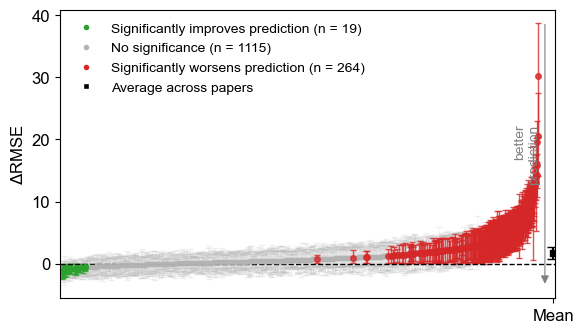

In [135]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ... same computation of delta_est_sorted, ci_low_sorted, ci_high_sorted,
# sig_better, sig_worse, sig_none, summary_est, summary_lo, summary_hi as before ...

fig, ax = plt.subplots(figsize=(6, 3.5))

x_papers = np.arange(n_papers)

# non-significant
for x, y, lo, hi in zip(
    x_papers[sig_none],
    delta_est_sorted[sig_none],
    ci_low_sorted[sig_none],
    ci_high_sorted[sig_none],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='0.7', ecolor='0.7',
        capsize=2, linewidth=0.5, markersize=3,
        alpha=0.2
    )

# significantly better (green)
for x, y, lo, hi in zip(
    x_papers[sig_better],
    delta_est_sorted[sig_better],
    ci_low_sorted[sig_better],
    ci_high_sorted[sig_better],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='tab:green', ecolor='tab:green',
        capsize=2, linewidth=1.0, markersize=4,
        alpha=0.8
    )

# significantly worse (red)
for x, y, lo, hi in zip(
    x_papers[sig_worse],
    delta_est_sorted[sig_worse],
    ci_low_sorted[sig_worse],
    ci_high_sorted[sig_worse],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='tab:red', ecolor='tab:red',
        capsize=2, linewidth=1.0, markersize=4,
        alpha=0.8
    )

# summary point (mean across papers)
gap = max(20, int(n_papers * 0.02))
x_summary = n_papers + gap
summary_yerr = [[summary_est - summary_lo], [summary_hi - summary_est]]

ax.errorbar(
    x_summary, summary_est, yerr=summary_yerr,
    fmt='s', color='black', ecolor='black',
    capsize=4, linewidth=1.5, markersize=5
)

# horizontal baseline
ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

# labels
ax.set_ylabel(r'$\Delta$RMSE')
ax.set_xticks([x_summary])
ax.set_xticklabels(['Mean'])
ax.set_xlim(-5, x_summary + 5)

# legend with counts, no numeric mean/CI in label
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'Significantly improves prediction (n = {n_better})',
           markerfacecolor='tab:green', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label=f'No significance (n = {n_none})',
           markerfacecolor='0.7', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label=f'Significantly worsens prediction (n = {n_worse})',
           markerfacecolor='tab:red', markersize=5),
    Line2D([0], [0], marker='s', color='w',
           label='Average across papers',
           markerfacecolor='black', markersize=5),
]

ax.legend(handles=legend_elements, loc='upper left',
          frameon=False, fontsize='small')

# --- "better prediction" arrow on the right ---

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

# x-position near the right edge
x_arrow = xmax - 0.02*(xmax - xmin)
y_top   = ymax - 0.05*(ymax - ymin)
y_bottom = ymin + 0.05*(ymax - ymin)

ax.annotate(
    '', xy=(x_arrow, y_bottom), xytext=(x_arrow, y_top),
    arrowprops=dict(
        arrowstyle='-|>',
        color='0.5',
        shrinkA=0, shrinkB=0,
        lw=0.8
    )
)

ax.text(
    x_arrow - 0.01*(xmax - xmin),  # slight left shift
    (y_top + y_bottom) / 2,
    'better\nprediction',
    color='0.5',
    rotation=90,
    va='center',
    ha='right',
    fontsize='small'
)

plt.tight_layout()
plt.show()

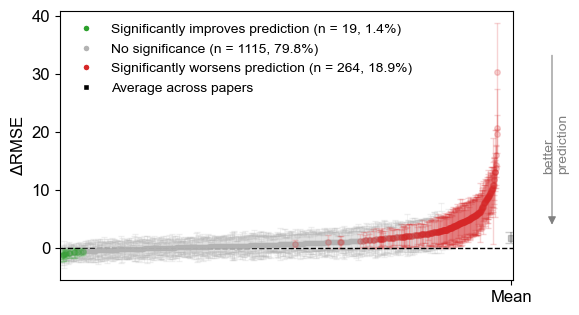

In [137]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

baseline_se = df_base_se['baseline'].values
n_papers = df_individual_se.shape[0]
n_pairs = baseline_se.shape[0]
n_boot = 500
rng = np.random.default_rng(seed=42)

def delta_rmse(se_model, se_base):
    rmse_model = np.sqrt(se_model.mean())
    rmse_base  = np.sqrt(se_base.mean())
    return rmse_model - rmse_base

def bootstrap_delta_rmse(se_model, se_base, n_boot=5000, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n = len(se_model)
    boot_vals = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_vals[b] = delta_rmse(se_model[idx], se_base[idx])
    lo, hi = np.percentile(boot_vals, [2.5, 97.5])
    return boot_vals.mean(), lo, hi

# --- ΔRMSE + CIs per paper ---
delta_est = np.empty(n_papers)
ci_low = np.empty(n_papers)
ci_high = np.empty(n_papers)

for i in range(n_papers):
    se_paper = df_individual_se.iloc[i].values
    est, lo, hi = bootstrap_delta_rmse(se_paper, baseline_se, n_boot=n_boot, rng=rng)
    delta_est[i] = est
    ci_low[i] = lo
    ci_high[i] = hi

# sort by ΔRMSE
order = np.argsort(delta_est)
delta_est_sorted = delta_est[order]
ci_low_sorted = ci_low[order]
ci_high_sorted = ci_high[order]

# significance masks
sig_better = ci_high_sorted < 0
sig_worse  = ci_low_sorted > 0
sig_none   = ~(sig_better | sig_worse)

n_better = int(sig_better.sum())
n_worse  = int(sig_worse.sum())
n_none   = int(sig_none.sum())

pct_better = 100 * n_better / n_papers
pct_worse  = 100 * n_worse  / n_papers
pct_none   = 100 * n_none   / n_papers

# summary: mean across papers (per config, then ΔRMSE)
mean_se_per_config = df_individual_se.mean(axis=0).values
summary_est, summary_lo, summary_hi = bootstrap_delta_rmse(
    mean_se_per_config, baseline_se, n_boot=n_boot, rng=rng
)

fig, ax = plt.subplots(figsize=(6, 3.5))

x_papers = np.arange(n_papers)

# non-significant (grey)
for x, y, lo, hi in zip(
    x_papers[sig_none],
    delta_est_sorted[sig_none],
    ci_low_sorted[sig_none],
    ci_high_sorted[sig_none],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='0.7', ecolor='0.7',
        capsize=2, linewidth=0.5, markersize=3,
        alpha=0.2, linestyle='none'
    )

# significantly better (green)
for x, y, lo, hi in zip(
    x_papers[sig_better],
    delta_est_sorted[sig_better],
    ci_low_sorted[sig_better],
    ci_high_sorted[sig_better],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='tab:green', ecolor='tab:green',
        capsize=2, linewidth=1.0, markersize=4,
        alpha=0.2, linestyle='none'
    )

# significantly worse (red)
for x, y, lo, hi in zip(
    x_papers[sig_worse],
    delta_est_sorted[sig_worse],
    ci_low_sorted[sig_worse],
    ci_high_sorted[sig_worse],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='tab:red', ecolor='tab:red',
        capsize=2, linewidth=1.0, markersize=4,
        alpha=0.2, linestyle='none'
    )

# summary point at the right
gap = max(20, int(n_papers * 0.02))
x_summary = n_papers + gap
summary_yerr = [[summary_est - summary_lo], [summary_hi - summary_est]]

ax.errorbar(
    x_summary, summary_est, yerr=summary_yerr,
    fmt='s', color='black', ecolor='black',
    capsize=4, linewidth=1.5, markersize=5,
    alpha=0.2, linestyle='none'
)

# horizontal baseline
ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

# axes labels / ticks
ax.set_ylabel(r'$\Delta$RMSE')
ax.set_xticks([x_summary])
ax.set_xticklabels(['Mean'])
ax.set_xlim(-5, x_summary + 5)

# legend with counts + percentages
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'Significantly improves prediction (n = {n_better}, {pct_better:.1f}%)',
           markerfacecolor='tab:green', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label=f'No significance (n = {n_none}, {pct_none:.1f}%)',
           markerfacecolor='0.7', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label=f'Significantly worsens prediction (n = {n_worse}, {pct_worse:.1f}%)',
           markerfacecolor='tab:red', markersize=5),
    Line2D([0], [0], marker='s', color='w',
           label='Average across papers',
           markerfacecolor='black', markersize=5),
]
ax.legend(handles=legend_elements, loc='upper left',
          frameon=False, fontsize='small')

# leave some room on the right for the arrow/text
plt.subplots_adjust(right=0.88)

# "better prediction" arrow + text *outside* the axes (in figure coords)
y0, y1 = 0.25, 0.75   # vertical span in figure fraction
x_arrow = 0.92        # to the right of the axes

ax.annotate(
    '', xy=(x_arrow, y0), xytext=(x_arrow, y1),
    xycoords='figure fraction', textcoords='figure fraction',
    arrowprops=dict(
        arrowstyle='-|>',
        color='0.5',
        lw=0.8
    )
)

fig.text(
    x_arrow + 0.01, (y0 + y1) / 2,
    'better\nprediction',
    color='0.5',
    rotation=90,
    va='center',
    ha='left',
    fontsize='small'
)

plt.show()

In [140]:
import numpy as np

# Squared errors
se_papers = df_individual_se.values            # shape (N, J)
baseline_se = df_base_se['baseline'].values    # shape (J,)

N, J = se_papers.shape
n_boot = 500  # can bump up/down as needed
rng = np.random.default_rng(42)

boot_means = np.empty(n_boot)

for b in range(n_boot):
    # 1) Resample designs with replacement
    idx_designs = rng.integers(0, J, size=J)

    se_papers_boot   = se_papers[:, idx_designs]      # (N, J)
    baseline_se_boot = baseline_se[idx_designs]       # (J,)

    # 2) RMSE per paper, and baseline RMSE
    rmse_papers_boot = np.sqrt(se_papers_boot.mean(axis=1))  # (N,)
    rmse_baseline_boot = np.sqrt(baseline_se_boot.mean())

    # 3) ΔRMSE per paper in this bootstrap
    delta_papers_boot = rmse_papers_boot - rmse_baseline_boot  # (N,)

    # 4) Resample papers and compute mean ΔRMSE
    idx_papers = rng.integers(0, N, size=N)
    boot_means[b] = delta_papers_boot[idx_papers].mean()

# Point estimate: mean ΔRMSE across papers on the *original* test set
delta_per_paper = np.sqrt(se_papers.mean(axis=1)) - np.sqrt(baseline_se.mean())
summary_est = delta_per_paper.mean()
summary_lo, summary_hi = np.percentile(boot_means, [2.5, 97.5])

In [142]:
summary_est

nan

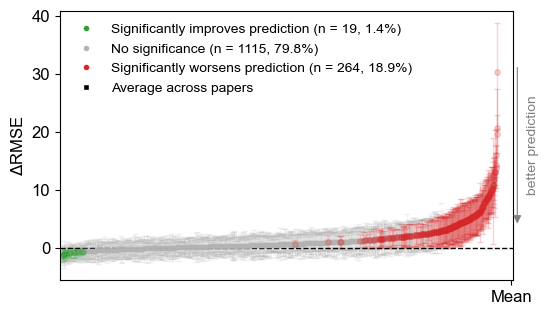

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# delta_est_sorted, ci_low_sorted, ci_high_sorted, sig_better, sig_worse, sig_none
# summary_est, summary_lo, summary_hi from hierarchical bootstrap

n_papers = len(delta_est_sorted)

n_better = int(sig_better.sum())
n_worse  = int(sig_worse.sum())
n_none   = int(sig_none.sum())

pct_better = 100 * n_better / n_papers
pct_worse  = 100 * n_worse  / n_papers
pct_none   = 100 * n_none   / n_papers

fig, ax = plt.subplots(figsize=(6, 3.5))

x_papers = np.arange(n_papers)

# Non-significant (grey)
for x, y, lo, hi in zip(
    x_papers[sig_none],
    delta_est_sorted[sig_none],
    ci_low_sorted[sig_none],
    ci_high_sorted[sig_none],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='0.7', ecolor='0.7',
        capsize=2, linewidth=0.5, markersize=3,
        alpha=0.2, linestyle='none'
    )

# Significantly better (green)
for x, y, lo, hi in zip(
    x_papers[sig_better],
    delta_est_sorted[sig_better],
    ci_low_sorted[sig_better],
    ci_high_sorted[sig_better],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='tab:green', ecolor='tab:green',
        capsize=2, linewidth=1.0, markersize=4,
        alpha=0.2, linestyle='none'
    )

# Significantly worse (red)
for x, y, lo, hi in zip(
    x_papers[sig_worse],
    delta_est_sorted[sig_worse],
    ci_low_sorted[sig_worse],
    ci_high_sorted[sig_worse],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='tab:red', ecolor='tab:red',
        capsize=2, linewidth=1.0, markersize=4,
        alpha=0.2, linestyle='none'
    )

# Summary point (hierarchical bootstrap) — solid black, no alpha
gap = max(20, int(n_papers * 0.02))
x_summary = n_papers + gap
summary_yerr = [[summary_est - summary_lo], [summary_hi - summary_est]]

ax.errorbar(
    x_summary, summary_est, yerr=summary_yerr,
    fmt='s', color='black', ecolor='black',
    capsize=4, linewidth=1.5, markersize=5,
    linestyle='none'
)

# Horizontal baseline
ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

# Axes
ax.set_ylabel(r'$\Delta$RMSE')
ax.set_xticks([x_summary])
ax.set_xticklabels(['Mean'])
ax.set_xlim(-5, x_summary + 5)

# Legend with counts + percentages
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'Significantly improves prediction (n = {n_better}, {pct_better:.1f}%)',
           markerfacecolor='tab:green', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label=f'No significance (n = {n_none}, {pct_none:.1f}%)',
           markerfacecolor='0.7', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label=f'Significantly worsens prediction (n = {n_worse}, {pct_worse:.1f}%)',
           markerfacecolor='tab:red', markersize=5),
    Line2D([0], [0], marker='s', color='w',
           label='Average across papers',
           markerfacecolor='black', markersize=5),
]
ax.legend(handles=legend_elements, loc='upper left',
          frameon=False, fontsize='small')

# Leave some space on the right for arrow + text
plt.subplots_adjust(right=0.88)

# --- "better prediction" arrow & text just outside the right axis ---

# Place arrow slightly outside axes in axes coordinates
x_arrow = 1.01
y_top, y_bottom = 0.8, 0.2

ax.annotate(
    '', xy=(x_arrow, y_bottom), xytext=(x_arrow, y_top),
    xycoords='axes fraction', textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='-|>',
        color='0.5',
        lw=0.8
    )
)

ax.text(
    x_arrow + 0.02, (y_top + y_bottom) / 2,
    'better prediction',
    color='0.5',
    rotation=90,
    va='center',
    ha='left',
    fontsize='small',
    transform=ax.transAxes
)

plt.show()

In [162]:
import numpy as np

# Squared errors: papers × designs
se_papers = df_individual_se.values           # shape (N, J)
baseline_se = df_base_se['baseline'].values   # shape (J,)

N, J = se_papers.shape

# Keep only designs where baseline and all paper SEs are finite
finite_designs = np.isfinite(baseline_se) & np.all(np.isfinite(se_papers), axis=0)
se_papers_clean = se_papers[:, finite_designs]
baseline_se_clean = baseline_se[finite_designs]

N, J_clean = se_papers_clean.shape
print(f"Using {J_clean} designs out of {J} (others had non-finite SEs).")

# Per-paper ΔRMSE on the original (cleaned) test set
rmse_papers = np.sqrt(np.nanmean(se_papers_clean, axis=1))   # (N,)
rmse_baseline = np.sqrt(np.nanmean(baseline_se_clean))       # scalar
delta_per_paper = rmse_papers - rmse_baseline                # (N,)

summary_est = delta_per_paper.mean()

# Hierarchical bootstrap: resample designs + papers
n_boot = 500
rng = np.random.default_rng(42)
boot_means = np.empty(n_boot)

for b in range(n_boot):
    # 1) Resample designs with replacement
    idx_designs = rng.integers(0, J_clean, size=J_clean)
    se_papers_boot = se_papers_clean[:, idx_designs]     # (N, J_clean)
    baseline_se_boot = baseline_se_clean[idx_designs]    # (J_clean,)

    # 2) RMSEs (skip any all-NaN case just in case)
    rmse_papers_boot = np.sqrt(np.nanmean(se_papers_boot, axis=1))   # (N,)
    rmse_baseline_boot = np.sqrt(np.nanmean(baseline_se_boot))       # scalar

    delta_papers_boot = rmse_papers_boot - rmse_baseline_boot        # (N,)
    finite = np.isfinite(delta_papers_boot)
    if not finite.any():
        boot_means[b] = np.nan
        continue

    # 3) Resample papers and compute mean ΔRMSE
    idx_papers = rng.integers(0, finite.sum(), size=finite.sum())
    boot_means[b] = delta_papers_boot[finite][idx_papers].mean()

# Drop any NaN draws defensively
boot_means = boot_means[np.isfinite(boot_means)]
summary_lo, summary_hi = np.percentile(boot_means, [2.5, 97.5])

print("Mean ΔRMSE across papers:", summary_est)
print("95% CI:", summary_lo, summary_hi)

Using 9 designs out of 20 (others had non-finite SEs).
Mean ΔRMSE across papers: 0.7926166959558946
95% CI: -0.30226157985708313 2.1376544289151758


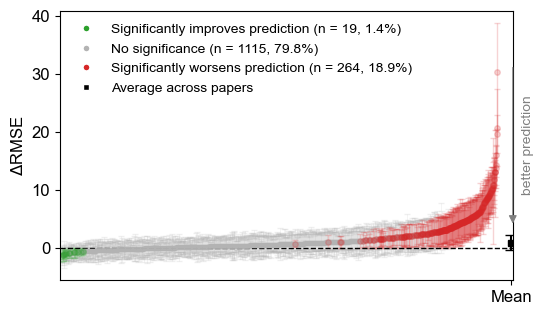

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

n_papers = len(delta_est_sorted)

n_better = int(sig_better.sum())
n_worse  = int(sig_worse.sum())
n_none   = int(sig_none.sum())

pct_better = 100 * n_better / n_papers
pct_worse  = 100 * n_worse  / n_papers
pct_none   = 100 * n_none   / n_papers

fig, ax = plt.subplots(figsize=(6, 3.5))

x_papers = np.arange(n_papers)

# Non-significant
for x, y, lo, hi in zip(
    x_papers[sig_none],
    delta_est_sorted[sig_none],
    ci_low_sorted[sig_none],
    ci_high_sorted[sig_none],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='0.7', ecolor='0.7',
        capsize=2, linewidth=0.5, markersize=3,
        alpha=0.2, linestyle='none'
    )

# Significantly better
for x, y, lo, hi in zip(
    x_papers[sig_better],
    delta_est_sorted[sig_better],
    ci_low_sorted[sig_better],
    ci_high_sorted[sig_better],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='tab:green', ecolor='tab:green',
        capsize=2, linewidth=1.0, markersize=4,
        alpha=0.2, linestyle='none'
    )

# Significantly worse
for x, y, lo, hi in zip(
    x_papers[sig_worse],
    delta_est_sorted[sig_worse],
    ci_low_sorted[sig_worse],
    ci_high_sorted[sig_worse],
):
    ax.errorbar(
        x, y,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        color='tab:red', ecolor='tab:red',
        capsize=2, linewidth=1.0, markersize=4,
        alpha=0.2, linestyle='none'
    )

# Summary point (hierarchical bootstrap), solid black
gap = max(20, int(n_papers * 0.02))
x_summary = n_papers + gap
summary_yerr = [[summary_est - summary_lo], [summary_hi - summary_est]]

ax.errorbar(
    x_summary, summary_est, yerr=summary_yerr,
    fmt='s', color='black', ecolor='black',
    capsize=4, linewidth=1.5, markersize=5,
    linestyle='none'
)

# Baseline line
ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

# Axes
ax.set_ylabel(r'$\Delta$RMSE')
ax.set_xticks([x_summary])
ax.set_xticklabels(['Mean'])
ax.set_xlim(-5, x_summary + 5)

# Legend with counts + percentages
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'Significantly improves prediction (n = {n_better}, {pct_better:.1f}%)',
           markerfacecolor='tab:green', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label=f'No significance (n = {n_none}, {pct_none:.1f}%)',
           markerfacecolor='0.7', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label=f'Significantly worsens prediction (n = {n_worse}, {pct_worse:.1f}%)',
           markerfacecolor='tab:red', markersize=5),
    Line2D([0], [0], marker='s', color='w',
           label='Average across papers',
           markerfacecolor='black', markersize=5),
]
ax.legend(handles=legend_elements, loc='upper left',
          frameon=False, fontsize='small')

# Tighten layout and reserve a bit of space for the arrow
plt.subplots_adjust(right=0.88)

# Arrow + text just outside the right axis
x_arrow = 1.0   # exactly at the right border in axes coords
y_top, y_bottom = 0.8, 0.2

ax.annotate(
    '', xy=(x_arrow, y_bottom), xytext=(x_arrow, y_top),
    xycoords='axes fraction', textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='-|>',
        color='0.5',
        lw=0.8
    )
)

ax.text(
    x_arrow + 0.02, (y_top + y_bottom) / 2,
    'better prediction',
    color='0.5',
    rotation=90,
    va='center',
    ha='left',
    fontsize='small',
    transform=ax.transAxes
)

plt.show()

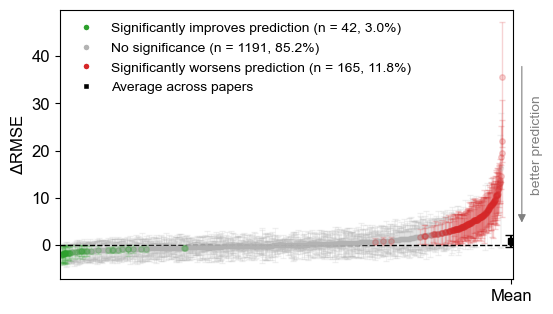

In [173]:
import numpy as np
import matplotlib.pyplot as plt

def plot_delta_rmse_individuals_simple(
    df_base_se,
    group_to_df,
    baseline_col="baseline",
    n_boot=2000,
    ax=None,
    random_state=42,
):
    """
    Simple per-forecaster ΔRMSE plot (forecaster − GPT-4.1 baseline).

    Parameters
    ----------
    df_base_se : pd.DataFrame
        Rows = designs, must contain a column `baseline_col`
        with squared errors (SE) for GPT-4.1 for each design.

    group_to_df : dict[str, pd.DataFrame]
        Mapping {group_name -> df_forecaster_se}.
        Each df_forecaster_se has:
          - rows = forecasters in that group
          - columns = designs (aligned with df_base_se rows)
          - values = squared error for that forecaster on that design.

    baseline_col : str
        Name of the baseline SE column in df_base_se.

    n_boot : int
        Number of bootstrap draws per forecaster for the CIs.

    ax : matplotlib.axes.Axes or None
        If provided, plot into this axes; otherwise create a new one.

    random_state : int
        Seed for RNG.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    rng = np.random.default_rng(random_state)

    # baseline SE: shape (J,)
    baseline_se = df_base_se[baseline_col].values
    J = len(baseline_se)

    # helper: bootstrap ΔRMSE for one forecaster
    def bootstrap_delta_rmse(se_model):
        # point estimate
        rmse_model = np.sqrt(np.nanmean(se_model))
        rmse_base = np.sqrt(np.nanmean(baseline_se))
        est = rmse_model - rmse_base

        # paired bootstrap over designs
        boot_vals = np.empty(n_boot)
        for b in range(n_boot):
            idx = rng.integers(0, J, size=J)
            se_m = se_model[idx]
            se_b = baseline_se[idx]
            rmse_m = np.sqrt(np.nanmean(se_m))
            rmse_b = np.sqrt(np.nanmean(se_b))
            boot_vals[b] = rmse_m - rmse_b

        lo, hi = np.percentile(boot_vals, [2.5, 97.5])
        return est, lo, hi

    # collect results across groups
    all_est = []
    all_lo = []
    all_hi = []
    all_group = []

    for group_name, df_se in group_to_df.items():
        se_forecasters = df_se.values  # shape (N_g, J)
        N_g, J_g = se_forecasters.shape
        assert J_g == J, "Design columns must align with df_base_se"

        for i in range(N_g):
            est, lo, hi = bootstrap_delta_rmse(se_forecasters[i, :])
            all_est.append(est)
            all_lo.append(lo)
            all_hi.append(hi)
            all_group.append(group_name)

    all_est = np.array(all_est)
    all_lo = np.array(all_lo)
    all_hi = np.array(all_hi)
    all_group = np.array(all_group)

    # significance flags
    sig_better = all_hi < 0        # CI entirely below 0
    sig_worse = all_lo > 0         # CI entirely above 0
    sig_none = ~(sig_better | sig_worse)

    # x positions: one column per group with jitter
    group_names = list(group_to_df.keys())
    x_centers = {g: i for i, g in enumerate(group_names)}  # 0,1,...
    jitter_width = 0.15

    xs = np.array([
        x_centers[g] + rng.uniform(-jitter_width, jitter_width)
        for g in all_group
    ])

    # --- plotting points (alpha = 0.2 everywhere) ---
    ax.scatter(xs[sig_none], all_est[sig_none],
               color='0.7', alpha=0.2, s=20,
               label="no significance")

    ax.scatter(xs[sig_better], all_est[sig_better],
               color='tab:green', alpha=0.2, s=25,
               label="significantly better than GPT-4.1")

    ax.scatter(xs[sig_worse], all_est[sig_worse],
               color='tab:red', alpha=0.2, s=25,
               label="significantly worse than GPT-4.1")

    # group medians as black diamonds
    for g, xc in x_centers.items():
        mask = (all_group == g)
        median_est = np.median(all_est[mask])
        ax.scatter(xc, median_est, marker='D',
                   color='black', s=40, zorder=3)

    # horizontal line at baseline (ΔRMSE = 0)
    ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

    # x-axis labels
    ax.set_xticks(list(x_centers.values()))
    ax.set_xticklabels(group_names)
    ax.set_ylabel(r'$\Delta$RMSE')

    # --- percentage text for each group: share significantly worse ---
    y_max = np.nanmax(all_est)
    y_min = np.nanmin(all_est)
    y_range = y_max - y_min if y_max > y_min else 1.0
    y_text = y_max + 0.08 * y_range  # a bit above the highest point

    for g, xc in x_centers.items():
        mask = (all_group == g)
        if mask.sum() == 0:
            continue
        frac_worse = sig_worse[mask].sum() / mask.sum()
        ax.text(xc, y_text,
                f"{100*frac_worse:.1f}% worse",
                ha='center', va='bottom',
                fontsize='small')

    # legend
    ax.legend(frameon=False, fontsize='small', loc='upper left')

    # --- down-facing arrow on the right: "better prediction" ---
    fig.subplots_adjust(right=0.88)
    x_arrow = 1.02  # slightly to the right of the axes
    y_top, y_bottom = 0.8, 0.2

    ax.annotate(
        '', xy=(x_arrow, y_bottom), xytext=(x_arrow, y_top),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(
            arrowstyle='-|>',
            color='0.5',
            lw=0.8
        )
    )
    ax.text(
        x_arrow + 0.02,
        (y_top + y_bottom) / 2,
        'better prediction',
        color='0.5',
        rotation=90,
        va='center',
        ha='left',
        fontsize='small',
        transform=ax.transAxes
    )

    return ax

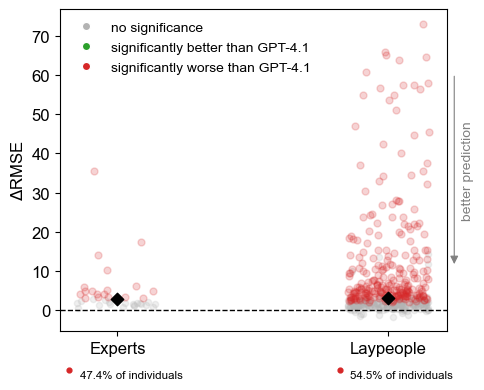

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Inputs ---
# df_base_se: rows = 20 config pairs, column 'baseline' = squared error per config
# df_individual_se: rows = papers (N), columns = same 20 configs (squared errors)

baseline_se = df_base_se['baseline'].values  # shape (20,)
rmse_base = np.sqrt(baseline_se.mean())

n_papers = df_collection_se.shape[0]
n_pairs = baseline_se.shape[0]
n_boot = 500
rng = np.random.default_rng(seed=42)

def delta_rmse(se_model, se_base):
    """RMSE(model) - RMSE(baseline) over the 20 configs."""
    rmse_model = np.sqrt(se_model.mean())
    rmse_base  = np.sqrt(se_base.mean())
    return rmse_model - rmse_base

def bootstrap_delta_rmse(se_model, se_base, n_boot=5000, rng=None):
    """Paired bootstrap over configs to get ΔRMSE + 95% CI for one model."""
    if rng is None:
        rng = np.random.default_rng()
    n = len(se_model)
    boot_vals = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)  # resample config indices
        boot_vals[b] = delta_rmse(se_model[idx], se_base[idx])
    lo, hi = np.percentile(boot_vals, [2.5, 97.5])
    return boot_vals.mean(), lo, hi

# --- Compute ΔRMSE and CIs per paper ---

delta_est = np.empty(n_papers)
ci_low = np.empty(n_papers)
ci_high = np.empty(n_papers)

for i in range(n_papers):
    se_paper = df_individual_se.iloc[i].values  # squared errors for paper i across 20 configs
    est, lo, hi = bootstrap_delta_rmse(se_paper, baseline_se, n_boot=n_boot, rng=rng)
    delta_est[i] = est
    ci_low[i] = lo
    ci_high[i] = hi

# Sort papers by ΔRMSE (best -> worst)
order = np.argsort(delta_est)
delta_est_sorted = delta_est[order]
ci_low_sorted = ci_low[order]
ci_high_sorted = ci_high[order]

# Determine significance for color-coding
sig_better = ci_high_sorted < 0    # CI entirely below 0
sig_worse  = ci_low_sorted > 0     # CI entirely above 0
sig_none   = ~(sig_better | sig_worse)

colors = np.full(n_papers, '0.7', dtype=object)  # default grey
colors[sig_better] = 'tab:green'
colors[sig_worse]  = 'tab:red'

# --- Summary point: "average paper" at far right ---

# One natural summary: average squared error across papers for each config,
# then compute ΔRMSE vs baseline.
mean_se_per_config = df_individual_se.mean(axis=0).values  # shape (20,)
summary_est, summary_lo, summary_hi = bootstrap_delta_rmse(
    mean_se_per_config, baseline_se, n_boot=n_boot, rng=rng
)

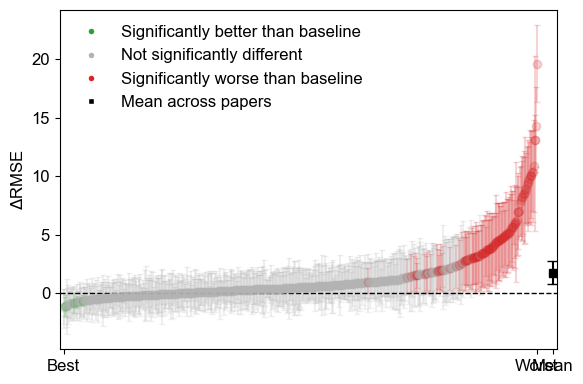

In [122]:
# --- Plot ---

fig, ax = plt.subplots(figsize=(6, 4))

# x positions for individual papers
x_papers = np.arange(n_papers)

# yerr for each paper
yerr_lower = delta_est_sorted - ci_low_sorted
yerr_upper = ci_high_sorted - delta_est_sorted

# Plot each paper as point+error bar, colored by significance
for x, y, lo, hi, c in zip(
    x_papers, delta_est_sorted, yerr_lower, yerr_upper, colors
):
    ax.errorbar(
        x, y,
        yerr=[[lo], [hi]],
        fmt='o',
        color=c,
        ecolor=c,
        capsize=2,
        linestyle='none',
        alpha=0.2
    )

# Add summary point at the right
gap = max(20, n_papers * 0.02)  # small visual gap
x_summary = n_papers + gap

summary_yerr = [[summary_est - summary_lo], [summary_hi - summary_est]]
ax.errorbar(
    x_summary, summary_est, yerr=summary_yerr,
    fmt='s', color='black', ecolor='black',
    capsize=4, linestyle='none', label='Mean across papers'
)

# Horizontal line at 0 (no change)
ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

# Axes + labels
ax.set_ylabel(r'$\Delta$RMSE')
ax.set_xlim(-5, x_summary + 5)

# We don't label every paper on x (too many); just mark the summary
ax.set_xticks([0, x_papers[-1], x_summary])
ax.set_xticklabels(['Best', 'Worst', 'Mean'])

# Legend for significance colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Significantly better than baseline',
           markerfacecolor='tab:green', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label='Not significantly different',
           markerfacecolor='0.7', markersize=5),
    Line2D([0], [0], marker='o', color='w',
           label='Significantly worse than baseline',
           markerfacecolor='tab:red', markersize=5),
    Line2D([0], [0], marker='s', color='w',
           label='Mean across papers',
           markerfacecolor='black', markersize=5),
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)

plt.tight_layout()
plt.show()